In [6]:
import os
print("Current directory:", os.getcwd())
print("\nFiles in current directory:")
print(os.listdir("."))
print("\nLooking for data folder:")
if os.path.exists("data"):
    print("data/ exists:", os.listdir("data"))
if os.path.exists("../data"):
    print("../data exists:", os.listdir("../data"))

Current directory: c:\Users\HP\climate-challenge-week0\src\notebooks

Files in current directory:
['all_countries_eda.ipynb', 'compare_countries.ipynb', 'ethiopia_eda.ipynb']

Looking for data folder:
../data exists: ['ethiopia_clean.csv', 'kenya_clean.csv', 'nigeria_clean.csv', 'sudan_clean.csv', 'tanzania_clean.csv']


In [27]:
# DEBUG: Check what data is loaded
print("Checking loaded data:")
print(f"Number of countries in all_data: {len(all_data)}")
print(f"Countries loaded: {list(all_data.keys())}")

for country in all_data:
    print(f"{country}: {len(all_data[country])} rows")

Checking loaded data:
Number of countries in all_data: 0
Countries loaded: []


In [38]:
import pandas as pd
import os

# Clear and reload all data
all_data = {}
countries = ['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']

# Get current directory - YOUR NOTEBOOK IS IN src/notebooks/
print(f"Current directory: {os.getcwd()}")

for country in countries:
    # Path: from src/notebooks/ go up two levels to main, then into data/
    file_path = f"../../data/{country}_clean.csv"
    
    print(f"Looking for: {file_path}")
    
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df['Date'] = pd.to_datetime(df['Date'])
        df['Month'] = df['Date'].dt.month
        df['Year'] = df['Date'].dt.year
        all_data[country] = df
        print(f"Loaded {country}: {len(df)} rows")
    else:
        print(f"NOT FOUND: {file_path}")

print(f"\nSuccessfully loaded {len(all_data)} countries")
print(f"Countries: {list(all_data.keys())}")

Current directory: c:\Users\HP\climate-challenge-week0\src\notebooks
Looking for: ../../data/ethiopia_clean.csv
NOT FOUND: ../../data/ethiopia_clean.csv
Looking for: ../../data/kenya_clean.csv
NOT FOUND: ../../data/kenya_clean.csv
Looking for: ../../data/nigeria_clean.csv
NOT FOUND: ../../data/nigeria_clean.csv
Looking for: ../../data/sudan_clean.csv
NOT FOUND: ../../data/sudan_clean.csv
Looking for: ../../data/tanzania_clean.csv
NOT FOUND: ../../data/tanzania_clean.csv

Successfully loaded 0 countries
Countries: []


In [29]:
import os

# Search for CSV files
print("Searching for CSV files...")

# Check different locations
paths_to_check = [
    "../../data/",
    "../data/",
    "data/",
    "C:/Users/HP/climate-challenge-week0/data/"
]

for path in paths_to_check:
    if os.path.exists(path):
        print(f"\nFiles in {path}:")
        for file in os.listdir(path):
            if file.endswith('_clean.csv'):
                print(f"  - {file}")
    else:
        print(f"Path does not exist: {path}")

Searching for CSV files...
Path does not exist: ../../data/

Files in ../data/:
  - ethiopia_clean.csv
  - kenya_clean.csv
  - nigeria_clean.csv
  - sudan_clean.csv
  - tanzania_clean.csv
Path does not exist: data/
Path does not exist: C:/Users/HP/climate-challenge-week0/data/


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Create plots folder
os.makedirs("../plots", exist_ok=True)

# List of countries
countries = ['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']
country_names = ['Ethiopia', 'Kenya', 'Nigeria', 'Sudan', 'Tanzania']

print("="*60)
print("TASK 3: CROSS-COUNTRY COMPARISON")
print("="*60)

# Load all cleaned data - CORRECT PATH IS ../data/
all_data = {}
for country in countries:
    file_path = f"../data/{country}_clean.csv"
    
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df['Date'] = pd.to_datetime(df['Date'])
        df['Month'] = df['Date'].dt.month
        df['Year'] = df['Date'].dt.year
        all_data[country] = df
        print(f"Loaded {country}: {len(df)} rows")
    else:
        print(f"Could not find: {file_path}")

print(f"\nSuccessfully loaded {len(all_data)} countries")

TASK 3: CROSS-COUNTRY COMPARISON
Loaded ethiopia: 4108 rows
Loaded kenya: 4108 rows
Loaded nigeria: 4108 rows
Loaded sudan: 4108 rows
Loaded tanzania: 4108 rows

Successfully loaded 5 countries



SECTION 1: TEMPERATURE TREND COMPARISON


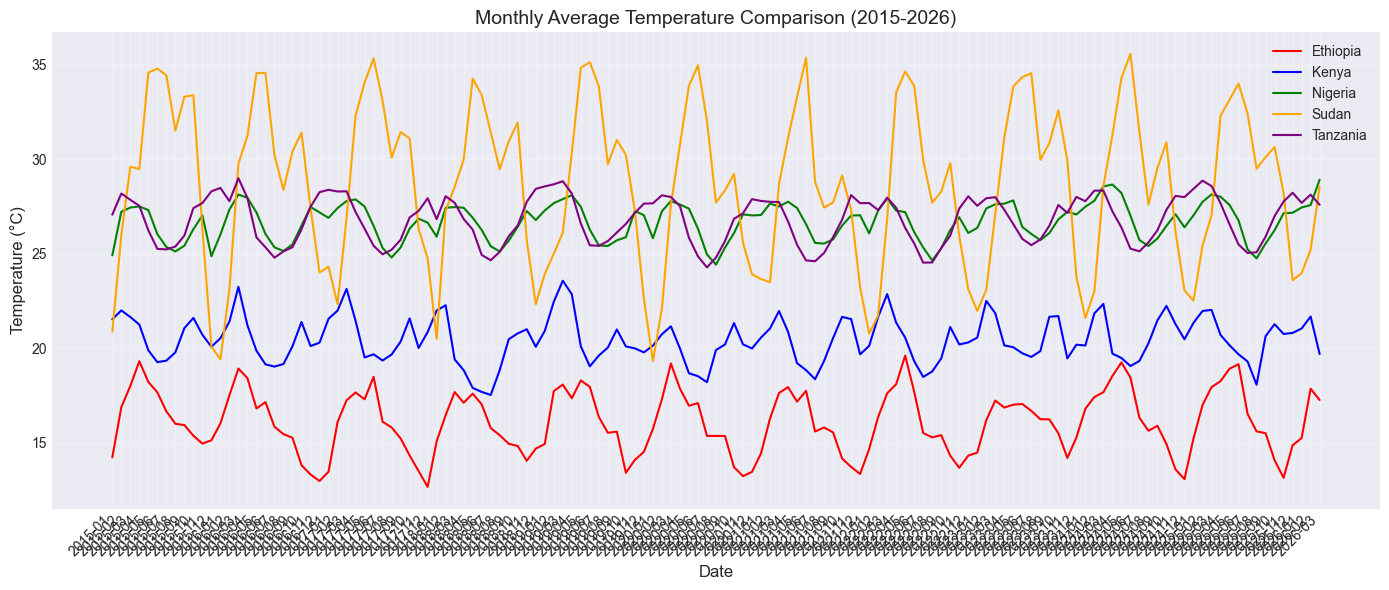

Temperature comparison plot saved


In [40]:
print("\n" + "="*60)
print("SECTION 1: TEMPERATURE TREND COMPARISON")
print("="*60)

# Calculate monthly average temperature per country
monthly_temp = {}
for country in countries:
    df = all_data[country]
    monthly_temp[country] = df.groupby(df['Date'].dt.to_period('M'))['T2M'].mean()

# Plot all countries together
plt.figure(figsize=(14, 6))
colors = ['red', 'blue', 'green', 'orange', 'purple']
for i, country in enumerate(countries):
    temp_series = monthly_temp[country]
    plt.plot(temp_series.index.astype(str), temp_series.values, 
             linewidth=1.5, color=colors[i], label=country.capitalize())

plt.title('Monthly Average Temperature Comparison (2015-2026)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/task3_temperature_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Temperature comparison plot saved")

In [32]:
print("\n" + "="*60)
print("SECTION 2: TEMPERATURE SUMMARY TABLE")
print("="*60)

temp_summary = []
for country in countries:
    df = all_data[country]
    temp_summary.append({
        'Country': country.capitalize(),
        'Mean T2M (°C)': round(df['T2M'].mean(), 1),
        'Median T2M (°C)': round(df['T2M'].median(), 1),
        'Std T2M (°C)': round(df['T2M'].std(), 1),
        'Min T2M (°C)': round(df['T2M'].min(), 1),
        'Max T2M (°C)': round(df['T2M'].max(), 1)
    })

temp_table = pd.DataFrame(temp_summary)
print(temp_table.to_string(index=False))

# Save
temp_table.to_csv('../plots/task3_temperature_summary.csv', index=False)
print("\n Temperature summary table saved")


SECTION 2: TEMPERATURE SUMMARY TABLE
 Country  Mean T2M (°C)  Median T2M (°C)  Std T2M (°C)  Min T2M (°C)  Max T2M (°C)
Ethiopia           16.1             16.0           1.9          10.0          21.5
   Kenya           20.4             20.4           1.4          15.3          25.4
 Nigeria           26.7             26.8           1.1          21.1          29.3
   Sudan           28.8             29.2           4.7          13.2          38.0
Tanzania           26.8             27.0           1.3          22.7          30.0

 Temperature summary table saved



SECTION 3: PRECIPITATION TREND COMPARISON


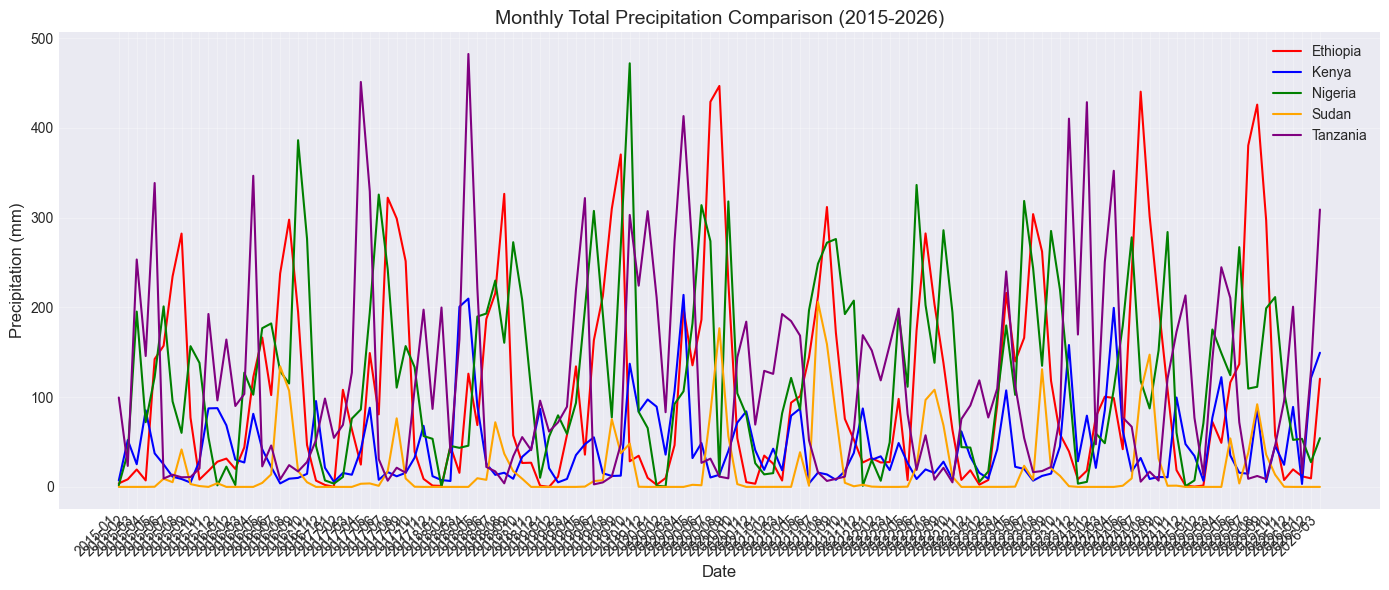

 Precipitation comparison plot saved


In [33]:
print("\n" + "="*60)
print("SECTION 3: PRECIPITATION TREND COMPARISON")
print("="*60)

# Calculate monthly total precipitation per country
monthly_rain = {}
for country in countries:
    df = all_data[country]
    monthly_rain[country] = df.groupby(df['Date'].dt.to_period('M'))['PRECTOTCORR'].sum()

# Plot all countries together
plt.figure(figsize=(14, 6))
for i, country in enumerate(countries):
    rain_series = monthly_rain[country]
    plt.plot(rain_series.index.astype(str), rain_series.values, 
             linewidth=1.5, color=colors[i], label=country.capitalize())

plt.title('Monthly Total Precipitation Comparison (2015-2026)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Precipitation (mm)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/task3_precipitation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Precipitation comparison plot saved")


SECTION 4: PRECIPITATION BOXPLOTS


C:\Users\HP\AppData\Local\Temp\ipykernel_13512\3094697073.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=names, patch_artist=True)


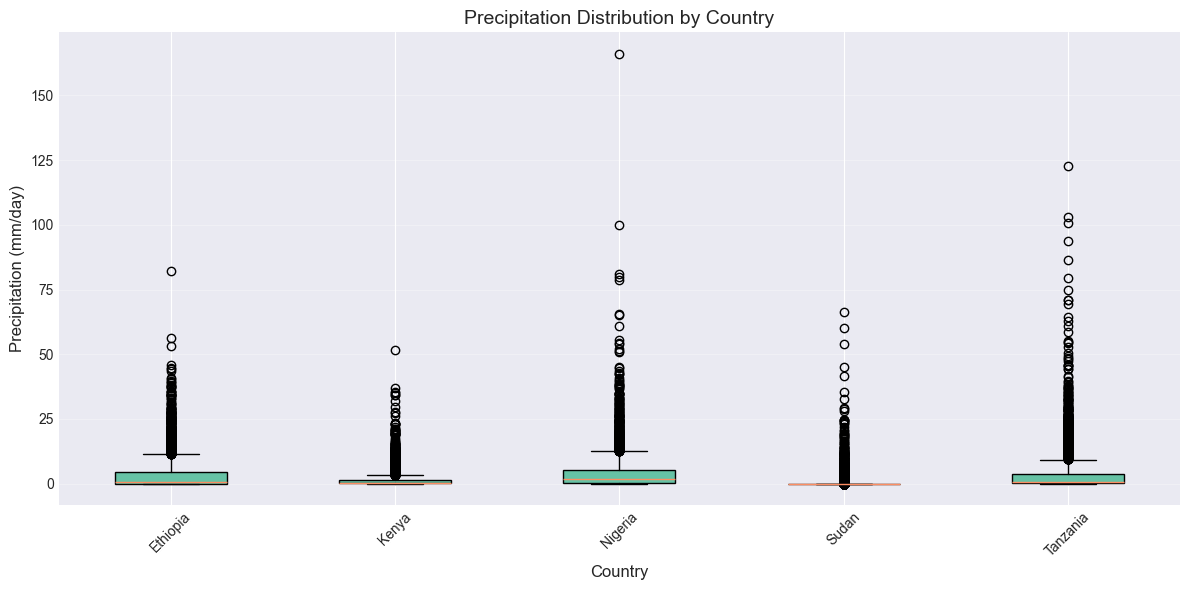

 Precipitation boxplots saved


In [34]:
print("\n" + "="*60)
print("SECTION 4: PRECIPITATION BOXPLOTS")
print("="*60)

# Prepare data
data_to_plot = []
names = []

for country in countries:
    data_to_plot.append(all_data[country]['PRECTOTCORR'].dropna().values)
    names.append(country.capitalize())

# Create plot
plt.figure(figsize=(12, 6))
plt.boxplot(data_to_plot, labels=names, patch_artist=True)
plt.title('Precipitation Distribution by Country', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Precipitation (mm/day)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../plots/task3_precipitation_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Precipitation boxplots saved")

In [35]:
print("\n" + "="*60)
print("SECTION 5: PRECIPITATION SUMMARY TABLE")
print("="*60)

rain_summary = []
for country in countries:
    df = all_data[country]
    rain_data = df['PRECTOTCORR']
    dry_days = (rain_data == 0).sum() / len(rain_data) * 100
    rain_summary.append({
        'Country': country.capitalize(),
        'Mean Rain (mm/day)': round(rain_data.mean(), 2),
        'Median Rain (mm/day)': round(rain_data.median(), 2),
        'Std Rain (mm/day)': round(rain_data.std(), 2),
        'Max Rain (mm/day)': round(rain_data.max(), 1),
        'Dry Days (%)': round(dry_days, 1)
    })

rain_table = pd.DataFrame(rain_summary)
print(rain_table.to_string(index=False))

# Save
rain_table.to_csv('../plots/task3_precipitation_summary.csv', index=False)
print("\n Precipitation summary table saved")


SECTION 5: PRECIPITATION SUMMARY TABLE
 Country  Mean Rain (mm/day)  Median Rain (mm/day)  Std Rain (mm/day)  Max Rain (mm/day)  Dry Days (%)
Ethiopia                3.63                  0.82               6.29               82.3          20.7
   Kenya                1.47                  0.38               3.18               51.6           6.3
 Nigeria                4.21                  1.84               7.27              166.1          11.8
   Sudan                0.64                  0.00               3.06               66.5          72.7
Tanzania                3.74                  0.64               8.00              122.6           5.2

 Precipitation summary table saved



SECTION 6: EXTREME EVENT FREQUENCY

 Extreme Heat Days (T2M_MAX > 35°C):
   Ethiopia: 0 days (0.0%)
   Kenya: 0 days (0.0%)
   Nigeria: 0 days (0.0%)
   Sudan: 2694 days (65.6%)
   Tanzania: 0 days (0.0%)

 Dry Days (PRECTOTCORR < 1mm):
   Ethiopia: 2,161 days (52.6%)
   Kenya: 2,831 days (68.9%)
   Nigeria: 1,595 days (38.8%)
   Sudan: 3,696 days (90.0%)
   Tanzania: 2,303 days (56.1%)


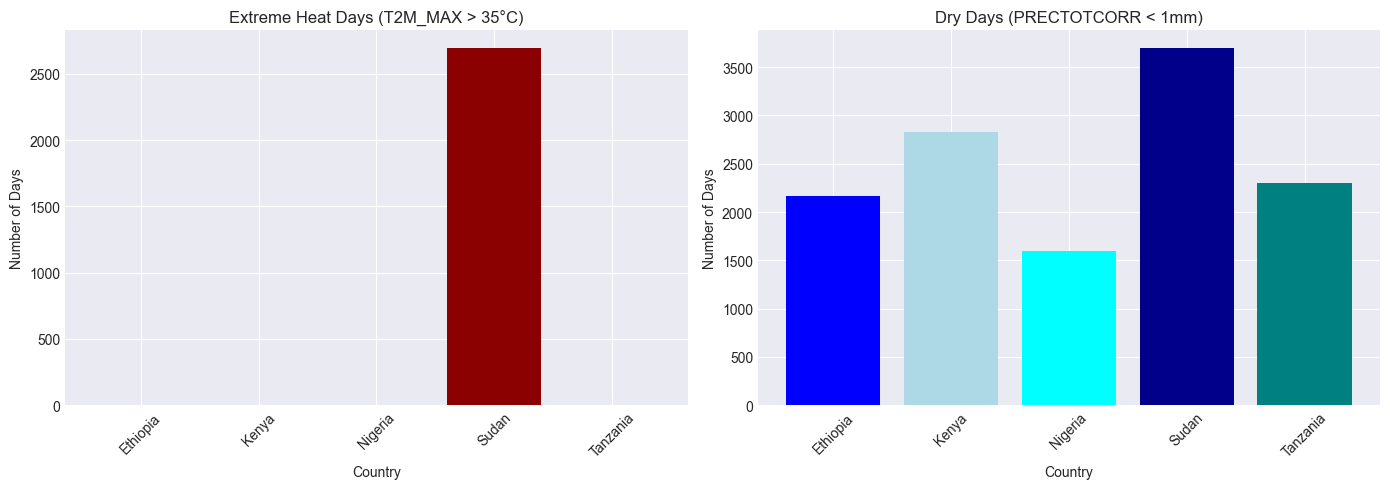


 Extreme events chart saved


In [36]:
print("\n" + "="*60)
print("SECTION 6: EXTREME EVENT FREQUENCY")
print("="*60)

# Heat days (T2M_MAX > 35°C)
print("\n Extreme Heat Days (T2M_MAX > 35°C):")
heat_days = {}
for country in countries:
    df = all_data[country]
    heat_count = (df['T2M_MAX'] > 35).sum()
    heat_pct = heat_count / len(df) * 100
    heat_days[country] = heat_count
    print(f"   {country.capitalize()}: {heat_count} days ({heat_pct:.1f}%)")

# Dry days (PRECTOTCORR < 1mm)
print("\n Dry Days (PRECTOTCORR < 1mm):")
dry_days = {}
for country in countries:
    df = all_data[country]
    dry_count = (df['PRECTOTCORR'] < 1).sum()
    dry_pct = dry_count / len(df) * 100
    dry_days[country] = dry_count
    print(f"   {country.capitalize()}: {dry_count:,} days ({dry_pct:.1f}%)")

# Bar chart for extreme events
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heat days bar chart
axes[0].bar(country_names, [heat_days[c] for c in countries], color=['red', 'orange', 'yellow', 'darkred', 'green'])
axes[0].set_title('Extreme Heat Days (T2M_MAX > 35°C)', fontsize=12)
axes[0].set_xlabel('Country', fontsize=10)
axes[0].set_ylabel('Number of Days', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)

# Dry days bar chart
axes[1].bar(country_names, [dry_days[c] for c in countries], color=['blue', 'lightblue', 'cyan', 'darkblue', 'teal'])
axes[1].set_title('Dry Days (PRECTOTCORR < 1mm)', fontsize=12)
axes[1].set_xlabel('Country', fontsize=10)
axes[1].set_ylabel('Number of Days', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../plots/task3_extreme_events.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Extreme events chart saved")

In [37]:
print("\n" + "="*60)
print("SECTION 7: CLIMATE VULNERABILITY RANKING")
print("="*60)

vulnerability = []
for country in countries:
    df = all_data[country]
    
    # Temperature score
    temp_score = df['T2M'].mean()
    
    # Heat extreme score
    heat_score = (df['T2M_MAX'] > 35).sum() / len(df) * 100
    
    # Dryness score
    dry_score = (df['PRECTOTCORR'] < 1).sum() / len(df) * 100
    
    # Rainfall variability
    rain_cv = df['PRECTOTCORR'].std() / (df['PRECTOTCORR'].mean() + 0.01)
    
    # Vulnerability index
    vuln_index = (temp_score / 30 * 0.3) + (heat_score / 50 * 0.3) + (dry_score / 80 * 0.25) + (min(rain_cv, 5) / 5 * 0.15)
    
    vulnerability.append({
        'Country': country.capitalize(),
        'Mean Temp (°C)': round(temp_score, 1),
        'Heat Days (%)': round(heat_score, 1),
        'Dry Days (%)': round(dry_score, 1),
        'Rain CV': round(rain_cv, 2),
        'Vulnerability Score': round(vuln_index * 100, 1)
    })

vuln_df = pd.DataFrame(vulnerability)
vuln_df = vuln_df.sort_values('Vulnerability Score', ascending=False)
print("\n CLIMATE VULNERABILITY RANKING (Higher Score = More Vulnerable)")
print("="*60)
print(vuln_df.to_string(index=False))

vuln_df.to_csv('../plots/task3_vulnerability_ranking.csv', index=False)
print("\n Vulnerability ranking saved")

print("\n" + "="*60)
print("TASK 3 IS COMPLETE!")
print("="*60)


SECTION 7: CLIMATE VULNERABILITY RANKING

 CLIMATE VULNERABILITY RANKING (Higher Score = More Vulnerable)
 Country  Mean Temp (°C)  Heat Days (%)  Dry Days (%)  Rain CV  Vulnerability Score
   Sudan            28.8           65.6          90.0     4.68                110.3
Tanzania            26.8            0.0          56.1     2.13                 50.7
   Kenya            20.4            0.0          68.9     2.15                 48.4
 Nigeria            26.7            0.0          38.8     1.72                 44.0
Ethiopia            16.1            0.0          52.6     1.73                 37.7

 Vulnerability ranking saved

TASK 3 IS COMPLETE!


In [41]:
print("=========Missing Sections-===========")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

=========Missing Sections-===========


In [42]:
# ============================================
# SECTION A: STATISTICAL TESTING (ANOVA)
# ============================================

print("\n" + "="*60)
print("SECTION A: STATISTICAL TESTING - ANOVA (KPI REQUIRED)")
print("="*60)

# Prepare data for ANOVA
temp_data = [all_data[country]['T2M'].values for country in countries]

# Run One-way ANOVA
f_stat, p_value = stats.f_oneway(*temp_data)

print(f"One-way ANOVA on Temperature (T2M) across 5 countries:")
print(f"   F-statistic: {f_stat:.4f}")
print(f"   P-value: {p_value:.10e}")

if p_value < 0.05:
    print(f"\nRESULT: p < 0.05 - Statistically SIGNIFICANT")
    print(f"   → The temperature differences between countries are real")
    print(f"   → Not due to random chance")
    print(f"   → This validates our vulnerability ranking")
else:
    print(f"\nRESULT: p > 0.05 - No significant difference")

# Run Kruskal-Wallis (non-parametric alternative)
h_stat, kw_p_value = stats.kruskal(*temp_data)
print(f"\nKruskal-Wallis Test (non-parametric):")
print(f"   H-statistic: {h_stat:.4f}")
print(f"   P-value: {kw_p_value:.10e}")

# Save results
anova_results = pd.DataFrame({
    'Test': ['ANOVA', 'Kruskal-Wallis'],
    'Statistic': [f_stat, h_stat],
    'P-value': [p_value, kw_p_value],
    'Significant': ['Yes' if p_value < 0.05 else 'No', 'Yes' if kw_p_value < 0.05 else 'No']
})
anova_results.to_csv('../plots/task3_anova_results.csv', index=False)
print("\nANOVA results saved")



SECTION A: STATISTICAL TESTING - ANOVA (KPI REQUIRED)
One-way ANOVA on Temperature (T2M) across 5 countries:
   F-statistic: 18938.7457
   P-value: 0.0000000000e+00

RESULT: p < 0.05 - Statistically SIGNIFICANT
   → The temperature differences between countries are real
   → Not due to random chance
   → This validates our vulnerability ranking

Kruskal-Wallis Test (non-parametric):
   H-statistic: 15392.9922
   P-value: 0.0000000000e+00

ANOVA results saved


In [ ]:
# ============================================
# SECTION B: CONSECUTIVE DRY DAYS
# ============================================

print("\n" + "="*60)
print("SECTION B: CONSECUTIVE DRY DAYS ANALYSIS")
print("="*60)

def max_consecutive_dry_days(rain_series):
    """Calculate maximum consecutive days with rain < 1mm"""
    max_streak = 0
    current_streak = 0
    for rain in rain_series:
        if rain < 1:
            current_streak += 1
            max_streak = max(max_streak, current_streak)
        else:
            current_streak = 0
    return max_streak

# Calculate per country
consecutive_dry_results = []
consecutive_dry = {}

for country in countries:
    df = all_data[country].copy()
    df['Year'] = df['Date'].dt.year
    yearly_max = df.groupby('Year')['PRECTOTCORR'].agg(lambda x: max_consecutive_dry_days(x.values))
    consecutive_dry[country] = yearly_max
    
    result = {
        'Country': country.capitalize(),
        'Avg Consecutive Dry Days': round(yearly_max.mean(), 0),
        'Longest Dry Spell (days)': yearly_max.max(),
        'Year of Longest Spell': yearly_max.idxmax()
    }
    consecutive_dry_results.append(result)
    print(f"\n{country.capitalize()}:")
    print(f"   Average consecutive dry days: {yearly_max.mean():.0f} days")
    print(f"   Longest dry spell: {yearly_max.max()} days ({yearly_max.idxmax()})")

consecutive_df = pd.DataFrame(consecutive_dry_results)
print("\n" + "="*60)
print("CONSECUTIVE DRY DAYS SUMMARY TABLE")
print("="*60)
print(consecutive_df.to_string(index=False))

# Save to CSV
consecutive_df.to_csv('../plots/task3_consecutive_dry_days.csv', index=False)

# Bar chart
plt.figure(figsize=(10, 6))
countries_list = [c.capitalize() for c in countries]
avg_consecutive = [consecutive_dry[c].mean() for c in countries]
bars = plt.bar(countries_list, avg_consecutive, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.title('Average Maximum Consecutive Dry Days per Year', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Days', fontsize=12)
plt.xticks(rotation=45)

for bar, val in zip(bars, avg_consecutive):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../plots/task3_consecutive_dry_days.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Consecutive dry days chart saved")